# Predicting the Next Word with OpenAI's LLM

This notebook demonstrates how a Large Language Model (LLM) like OpenAI's GPT-3.5 predicts the next word in a sentence using token probabilities and log probabilities.

We will:
- Set up the environment
- Call the OpenAI API to get next-token predictions with log probabilities
- Convert log probabilities to normalized probabilities
- Visualize the distribution of possible next tokens


## Setup: Install Required Libraries

First, we install the necessary packages: `openai` for interacting with the OpenAI API, `numpy` for numerical computations, and `matplotlib` for visualization.


In [ ]:
!pip install -q openai numpy matplotlib

## Import Libraries and Set API Key

Import the required libraries. Replace `"YOUR_OPENAI_API_KEY"` with your actual OpenAI API key to authenticate API requests.


In [ ]:
import os
from openai import OpenAI
import numpy as np
import matplotlib.pyplot as plt




client = OpenAI(
    api_key="your-api-key"
)


## Define the Prompt

Here, we define the partial sentence for which we want the LLM to predict the next word. The model will produce probabilities for possible next tokens following this prompt.


In [ ]:
sentence = "After years of hard work, your effort will take you"


## Request Next Token Predictions with Log Probabilities

We call the OpenAI API with parameters to get the next token prediction. We set `max_tokens=1` to get one token, `logprobs=50` to retrieve log probabilities for the top 50 potential tokens, and `temperature=0` to make the prediction deterministic.


In [ ]:
response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "user", "content": sentence}
    ],
    max_tokens=1,
    logprobs=True,
    top_logprobs=20,
    temperature=0
)

## Extract and Convert Log Probabilities into Probabilities

The API response contains log probabilities for the candidate tokens. We convert these log values into actual probabilities by applying the exponential function and normalize so they sum to 1.


In [ ]:
logprobs_list = response.choices[0].logprobs.content[0].top_logprobs

print(f"Number of top logprobs received: {len(logprobs_list)}")


probs = {item.token: np.exp(item.logprob) for item in logprobs_list}

total = sum(probs.values())
probs = {token: prob / total for token, prob in probs.items()}


Number of top logprobs received: 20


## Sort Tokens by Probability and Display Top 10

Tokens are sorted by their probabilities in descending order. We then display the top 10 tokens with their associated probabilities as percentages.


In [ ]:
sorted_items = sorted(probs.items(), key=lambda x: x[1], reverse=True)

print("\nTop 10 tokens with their probabilities:")
for token, prob in sorted_items[:10]:
    print(f"'{token}': {prob:.3%}")



Top 10 tokens with their probabilities:
'to': 90.699%
'After': 7.445%
'far': 0.785%
'...': 0.371%
'clos': 0.371%
'tow': 0.155%
'places': 0.039%
'on': 0.034%
'where': 0.021%
'To': 0.018%


## Visualize the Probability Distribution of Next Tokens

Finally, we visualize all candidate tokens' probabilities using a horizontal bar chart. This gives an intuitive view of how confident the model is about each possible next token.


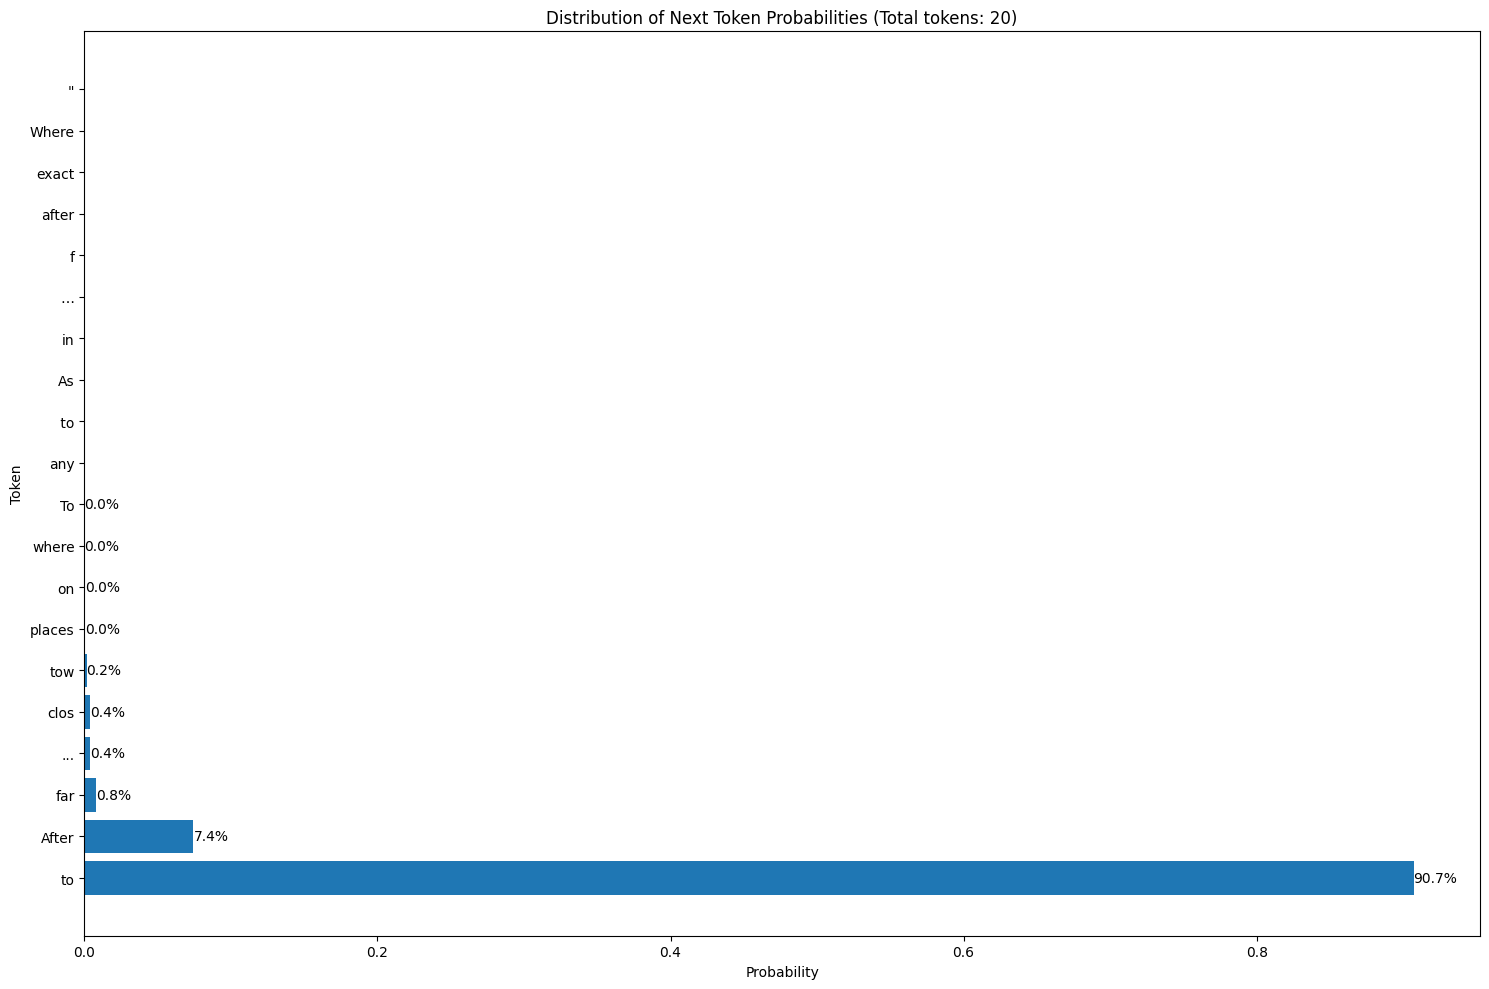

In [ ]:
tokens, probabilities = zip(*sorted_items)

plt.figure(figsize=(15, 10))
plt.barh(range(len(tokens)), probabilities)
plt.yticks(range(len(tokens)), tokens)
plt.title(f'Distribution of Next Token Probabilities (Total tokens: {len(tokens)})')
plt.xlabel('Probability')
plt.ylabel('Token')

for i, prob in enumerate(probabilities[:10]):
    plt.text(prob, i, f'{prob:.1%}', va='center')

plt.tight_layout()
plt.show()
